In [1]:
from Configurations.imports import *

In [2]:
from sklearn.datasets import make_classification

# create dataset
X, y = make_classification(
    n_samples=500,      # number of samples
    n_features=5,       # total features
    n_informative=3,    # useful features
    n_redundant=1,      # correlated features
    n_classes=2,        # binary classification
    random_state=42
)

# convert to dataframe
df = pd.DataFrame(X, columns=[
    "feature1",
    "feature2",
    "feature3",
    "feature4",
    "feature5"
])

df["target"] = y

print(df.head())

   feature1  feature2  feature3  feature4  feature5  target
0 -1.299565  0.608232 -1.518449  1.004770  1.495378       1
1 -0.273844  1.358806  1.194674  1.223679  2.467322       1
2 -2.510600 -2.423153 -0.768365  2.434551  1.227190       0
3  0.374002 -0.794579 -0.093434 -1.252782 -2.123091       0
4  0.378860  1.193772 -0.187534  0.633405  1.692101       1


In [4]:
# train and test split of the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((400, 5), (100, 5))

In [5]:
# Basic training model
from sklearn.ensemble import GradientBoostingClassifier
classifier = GradientBoostingClassifier()
classifier.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [6]:
y_pred = classifier.predict(x_test)

In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93        58
           1       0.93      0.88      0.90        42

    accuracy                           0.92       100
   macro avg       0.92      0.91      0.92       100
weighted avg       0.92      0.92      0.92       100



loss: Literal['log_loss', 'deviance', 'exponential'] = "log_loss",
    learning_rate: Float = 0.1,
    n_estimators: Int = 100,
    subsample: Float = 1,
    criterion: Literal['friedman_mse', 'squared_error'] = "friedman_mse",
    min_samples_split: float = 2,
    min_samples_leaf: float = 1,
    min_weight_fraction_leaf: Float = 0,
    max_depth: int | None = 3,
    min_impurity_decrease: Float = 0,

In [15]:
# Hyper Parameter tuning
"""params  is initializing a dictionary in Python named `params`. This dictionary will be used to store hyperparameters for hyperparameter tuning in a machine learning model. Each key in the dictionary represents a hyperparameter, and the corresponding value is a list of possible values that will be tested during the tuning process."""

params = {
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[300,500,700],
    "max_depth":[3,4,5],
    "min_samples_split":[50,25,10],
    "min_samples_leaf":[10,5,3]
}

In [12]:
from sklearn.model_selection import GridSearchCV
search = GridSearchCV(estimator=classifier, param_grid=params, cv = 5, n_jobs=-1, scoring="precision", refit=True)

In [13]:
search.fit(x_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [10, 5, ...], 'min_samples_split': [50, 25, ...], ...}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [16]:
y_pred = search.predict(x_test)

In [18]:
search.best_params_

{'learning_rate': 0.05,
 'max_depth': 5,
 'min_samples_leaf': 5,
 'min_samples_split': 10,
 'n_estimators': 700}

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92        58
           1       0.90      0.88      0.89        42

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



In [19]:
from sklearn.metrics import roc_curve
fpr,tpr, thresholds = roc_curve(y_test,y_pred)

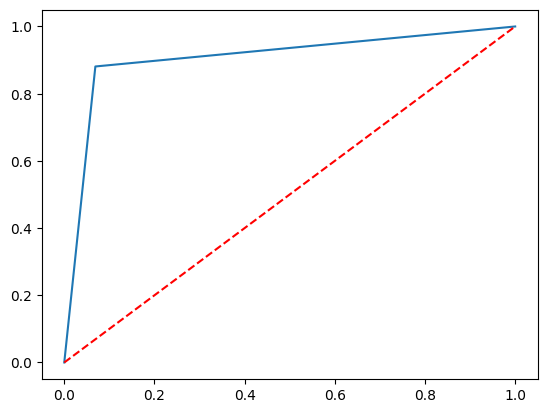

In [21]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"r--")